# 02 Training Clinic


In [1]:
from __future__ import annotations

from pathlib import Path
import copy
import json
import math
import random
from dataclasses import dataclass, asdict

import numpy as np

try:
    import matplotlib.pyplot as plt
except ImportError:
    plt = None

import torch
import torch.nn as nn
import torch.nn.functional as F

try:
    import pandas as pd
except ImportError:
    pd = None

if plt is not None:
    plt.style.use('seaborn-v0_8-whitegrid')


In [2]:
# Reproducibility helpers

def set_global_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    # MLP-only training on CPU should be compatible with deterministic algorithms.
    torch.use_deterministic_algorithms(True)


def accuracy_from_logits(logits: torch.Tensor, y_true: torch.Tensor) -> float:
    preds = torch.argmax(logits, dim=1)
    return float((preds == y_true).float().mean().item())


In [3]:
# Dataset loading (reused from 01_data_and_baselines.ipynb)
DATA_ROOT = Path('UCI-HAR Dataset')
INERTIAL_CHANNELS = [
    'body_acc_x', 'body_acc_y', 'body_acc_z',
    'body_gyro_x', 'body_gyro_y', 'body_gyro_z',
    'total_acc_x', 'total_acc_y', 'total_acc_z',
]


def load_activity_map(root: Path):
    names = [line.strip().split()[1] for line in (root / 'activity_labels.txt').read_text().splitlines() if line.strip()]
    ids = np.arange(1, len(names) + 1).tolist()
    return dict(zip(ids, names))


def load_split(split: str, root: Path = DATA_ROOT):
    split_dir = root / split
    sig_dir = split_dir / 'Inertial Signals'
    channel_arrays = []
    for ch in INERTIAL_CHANNELS:
        arr = np.loadtxt(sig_dir / f'{ch}_{split}.txt')
        channel_arrays.append(arr)
    X = np.stack(channel_arrays, axis=-1)
    y = np.loadtxt(split_dir / f'y_{split}.txt', dtype=int)
    subjects = np.loadtxt(split_dir / f'subject_{split}.txt', dtype=int)
    return X, y, subjects


X_train, y_train, subj_train = load_split('train')
X_test, y_test, subj_test = load_split('test')
activity_map = load_activity_map(DATA_ROOT)

print('Loaded UCI HAR')
print('X_train:', X_train.shape, 'y_train:', y_train.shape)
print('X_test :', X_test.shape, 'y_test :', y_test.shape)


Loaded UCI HAR
X_train: (7352, 128, 9) y_train: (7352,)
X_test : (2947, 128, 9) y_test : (2947,)


In [4]:
# reusable split function
def make_subject_disjoint_fit_val_split(X, y, subjects, val_subject_fraction=0.2, split_seed=42):
    rng = np.random.default_rng(split_seed)
    subject_ids = np.unique(subjects)
    shuffled = rng.permutation(subject_ids)
    n_val_subjects = max(1, int(round(val_subject_fraction * len(subject_ids))))
    val_subjects = set(shuffled[:n_val_subjects].tolist())
    fit_subjects = set(shuffled[n_val_subjects:].tolist())

    fit_mask = np.isin(subjects, list(fit_subjects))
    val_mask = np.isin(subjects, list(val_subjects))

    X_fit = X[fit_mask]
    y_fit = y[fit_mask]
    X_val = X[val_mask]
    y_val = y[val_mask]
    subj_fit = subjects[fit_mask]
    subj_val = subjects[val_mask]

    overlap = set(np.unique(subj_fit)).intersection(set(np.unique(subj_val)))
    assert len(overlap) == 0, f'Subject overlap detected: {overlap}'

    return {
        'X_fit': X_fit,
        'y_fit': y_fit,
        'X_val': X_val,
        'y_val': y_val,
        'subj_fit': subj_fit,
        'subj_val': subj_val,
        'fit_subjects': sorted(fit_subjects),
        'val_subjects': sorted(val_subjects),
        'split_seed': split_seed,
    }


split = make_subject_disjoint_fit_val_split(X_train, y_train, subj_train, val_subject_fraction=0.2, split_seed=42)
print('Fit windows:', split['X_fit'].shape[0], 'Val windows:', split['X_val'].shape[0])
print('Fit subjects:', len(split['fit_subjects']), 'Val subjects:', len(split['val_subjects']))


Fit windows: 5800 Val windows: 1552
Fit subjects: 17 Val subjects: 4


In [5]:
@dataclass
class RunConfig:
    name: str
    note: str
    seed: int = 42
    split_seed: int = 42
    batch_size: int = 256
    epochs: int = 20
    lr: float = 1e-3
    weight_decay: float = 0.0
    hidden_dims: tuple[int, ...] = (128, 64)
    dropout: float = 0.0
    optimizer: str = 'adam'        
    momentum: float = 0.9           
    grad_clip_norm: float | None = None
    early_stopping_patience: int | None = None
    min_delta: float = 0.0
    restore_best_weights: bool = True
    scheduler: str | None = None    
    step_size: int = 10
    gamma: float = 0.5
    plateau_patience: int = 5
    plateau_factor: float = 0.5
    noise_std: float = 0.0         
    fit_fraction: float = 1.0        


class MLP(nn.Module):
    def __init__(self, in_dim: int, hidden_dims: tuple[int, ...], n_classes: int, dropout: float = 0.0):
        super().__init__()
        layers = []
        prev = in_dim
        for h in hidden_dims:
            layers.append(nn.Linear(prev, h))
            layers.append(nn.ReLU())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            prev = h
        layers.append(nn.Linear(prev, n_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def prepare_arrays_for_training(split_dict, split_seed: int, fit_fraction: float = 1.0):
    base = make_subject_disjoint_fit_val_split(X_train, y_train, subj_train, split_seed=split_seed)
    X_fit = base['X_fit'].reshape(base['X_fit'].shape[0], -1).astype(np.float32)
    X_val = base['X_val'].reshape(base['X_val'].shape[0], -1).astype(np.float32)
    y_fit = (base['y_fit'] - 1).astype(np.int64)
    y_val = (base['y_val'] - 1).astype(np.int64)

    mean = X_fit.mean(axis=0, keepdims=True)
    std = X_fit.std(axis=0, keepdims=True) + 1e-6
    X_fit = (X_fit - mean) / std
    X_val = (X_val - mean) / std

    # Optional downsampling to intentionally make overfitting easier to trigger
    if fit_fraction < 1.0:
        rng = np.random.default_rng(split_seed + 777)
        n = X_fit.shape[0]
        k = max(32, int(round(fit_fraction * n)))
        idx = rng.choice(n, size=k, replace=False)
        idx = np.sort(idx)
        X_fit = X_fit[idx]
        y_fit = y_fit[idx]

    return X_fit, y_fit, X_val, y_val, base


def evaluate_model(model, X_t, y_t, criterion):
    model.eval()
    with torch.no_grad():
        logits = model(X_t)
        loss = criterion(logits, y_t).item()
        acc = accuracy_from_logits(logits, y_t)
    return loss, acc


def train_run(cfg: RunConfig, device: str = 'cpu'):
    set_global_seed(cfg.seed)
    torch.set_num_threads(max(1, torch.get_num_threads()))

    X_fit_np, y_fit_np, X_val_np, y_val_np, split_meta = prepare_arrays_for_training(
        split, split_seed=cfg.split_seed, fit_fraction=cfg.fit_fraction
    )

    X_fit_t = torch.from_numpy(X_fit_np).to(device)
    y_fit_t = torch.from_numpy(y_fit_np).to(device)
    X_val_t = torch.from_numpy(X_val_np).to(device)
    y_val_t = torch.from_numpy(y_val_np).to(device)

    n_classes = int(np.max(y_train))
    model = MLP(X_fit_t.shape[1], cfg.hidden_dims, n_classes, dropout=cfg.dropout).to(device)
    criterion = nn.CrossEntropyLoss()

    if cfg.optimizer.lower() == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay)
    elif cfg.optimizer.lower() == 'sgd':
        optimizer = torch.optim.SGD(model.parameters(), lr=cfg.lr, momentum=cfg.momentum, weight_decay=cfg.weight_decay)
    else:
        raise ValueError(f'Unsupported optimizer: {cfg.optimizer}')

    scheduler = None
    if cfg.scheduler == 'step':
        scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=cfg.step_size, gamma=cfg.gamma)
    elif cfg.scheduler == 'plateau':
        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='min', factor=cfg.plateau_factor, patience=cfg.plateau_patience
        )

    history = {
        'epoch': [],
        'train_loss': [],
        'val_loss': [],
        'train_acc': [],
        'val_acc': [],
        'lr': [],
    }
    best = {
        'epoch': -1,
        'val_loss': math.inf,
        'val_acc': -math.inf,
        'state_dict': None,
    }
    failure_reason = None
    stopped_early = False
    bad_epochs = 0
    n_fit = X_fit_t.shape[0]

    for epoch in range(1, cfg.epochs + 1):
        model.train()
        perm_gen = torch.Generator(device=device)
        perm_gen.manual_seed(cfg.seed + 10_000 + epoch)
        perm = torch.randperm(n_fit, generator=perm_gen, device=device)

        epoch_loss_sum = 0.0
        epoch_count = 0

        for i in range(0, n_fit, cfg.batch_size):
            idx = perm[i:i + cfg.batch_size]
            xb = X_fit_t[idx]
            yb = y_fit_t[idx]
            if cfg.noise_std > 0:
                noise = torch.randn_like(xb) * cfg.noise_std
                xb = xb + noise

            logits = model(xb)
            loss = criterion(logits, yb)

            if not torch.isfinite(loss):
                failure_reason = f'non-finite loss at epoch {epoch}'
                break

            optimizer.zero_grad(set_to_none=True)
            loss.backward()
            if cfg.grad_clip_norm is not None:
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip_norm)
            optimizer.step()

            epoch_loss_sum += float(loss.item()) * len(idx)
            epoch_count += len(idx)

        if failure_reason is not None:
            break

        train_loss, train_acc = evaluate_model(model, X_fit_t, y_fit_t, criterion)
        val_loss, val_acc = evaluate_model(model, X_val_t, y_val_t, criterion)

        history['epoch'].append(epoch)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_acc'].append(train_acc)
        history['val_acc'].append(val_acc)
        history['lr'].append(float(optimizer.param_groups[0]['lr']))

        improved = False
        if val_acc > best['val_acc'] + cfg.min_delta:
            improved = True
        elif abs(val_acc - best['val_acc']) <= 1e-12 and val_loss < best['val_loss']:
            improved = True

        if improved:
            best['epoch'] = epoch
            best['val_acc'] = val_acc
            best['val_loss'] = val_loss
            best['state_dict'] = copy.deepcopy(model.state_dict())
            bad_epochs = 0
        else:
            bad_epochs += 1

        if scheduler is not None:
            if cfg.scheduler == 'plateau':
                scheduler.step(val_loss)
            else:
                scheduler.step()

        if cfg.early_stopping_patience is not None and bad_epochs >= cfg.early_stopping_patience:
            stopped_early = True
            break

    if cfg.restore_best_weights and best['state_dict'] is not None:
        model.load_state_dict(best['state_dict'])

    final_train_loss, final_train_acc = evaluate_model(model, X_fit_t, y_fit_t, criterion)
    final_val_loss, final_val_acc = evaluate_model(model, X_val_t, y_val_t, criterion)

    summary = {
        'run_name': cfg.name,
        'note': cfg.note,
        'seed': cfg.seed,
        'split_seed': cfg.split_seed,
        'epochs_requested': cfg.epochs,
        'epochs_ran': len(history['epoch']),
        'hidden_dims': list(cfg.hidden_dims),
        'dropout': cfg.dropout,
        'weight_decay': cfg.weight_decay,
        'optimizer': cfg.optimizer,
        'lr': cfg.lr,
        'batch_size': cfg.batch_size,
        'noise_std': cfg.noise_std,
        'scheduler': cfg.scheduler or 'none',
        'early_stopping_patience': cfg.early_stopping_patience,
        'grad_clip_norm': cfg.grad_clip_norm,
        'fit_fraction': cfg.fit_fraction,
        'best_epoch': int(best['epoch']) if best['epoch'] != -1 else None,
        'best_val_acc': float(best['val_acc']) if best['epoch'] != -1 else float('nan'),
        'best_val_loss': float(best['val_loss']) if best['epoch'] != -1 else float('nan'),
        'final_train_acc': float(final_train_acc),
        'final_val_acc': float(final_val_acc),
        'final_train_loss': float(final_train_loss),
        'final_val_loss': float(final_val_loss),
        'generalization_gap_acc': float(final_train_acc - final_val_acc),
        'stopped_early': bool(stopped_early),
        'failure_reason': failure_reason,
        'fit_windows': int(X_fit_t.shape[0]),
        'val_windows': int(X_val_t.shape[0]),
        'fit_subjects': len(split_meta['fit_subjects']),
        'val_subjects': len(split_meta['val_subjects']),
    }

    return {
        'config': cfg,
        'model': model,
        'history': history,
        'summary': summary,
    }


def plot_history(result, metric='acc'):
    if plt is None:
        print('matplotlib is not installed; skipping plot for', result['summary']['run_name'])
        return
    h = result['history']
    name = result['summary']['run_name']
    if len(h['epoch']) == 0:
        print(f"{name}: no history recorded (failure before first epoch).")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(h['epoch'], h['train_loss'], label='train_loss')
    axes[0].plot(h['epoch'], h['val_loss'], label='val_loss')
    axes[0].set_title(f'{name} - Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Cross-entropy')
    axes[0].legend()

    axes[1].plot(h['epoch'], h['train_acc'], label='train_acc')
    axes[1].plot(h['epoch'], h['val_acc'], label='val_acc')
    axes[1].set_title(f'{name} - Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()

    plt.tight_layout()
    plt.show()


def compare_runs(results, title='Comparison'):
    rows = []
    for r in results:
        s = r['summary']
        rows.append({
            'run_name': s['run_name'],
            'seed': s['seed'],
            'epochs_ran': s['epochs_ran'],
            'best_epoch': s['best_epoch'],
            'best_val_acc': round(s['best_val_acc'], 4),
            'final_val_acc': round(s['final_val_acc'], 4),
            'final_train_acc': round(s['final_train_acc'], 4),
            'gap(train-val)': round(s['generalization_gap_acc'], 4),
            'failure_reason': s['failure_reason'],
            'note': s['note'],
        })
    print(title)
    if pd is not None:
        display(pd.DataFrame(rows))
    else:
        print(json.dumps(rows, indent=2))


In [6]:
RUNS = []

def add_run(cfg: RunConfig):
    result = train_run(cfg)
    RUNS.append(result)
    s = result['summary']
    print(f"[{s['run_name']}] best_val_acc={s['best_val_acc']:.4f} @ epoch {s['best_epoch']} | final_val_acc={s['final_val_acc']:.4f} | final_train_acc={s['final_train_acc']:.4f}")
    if s['failure_reason']:
        print('failure_reason:', s['failure_reason'])
    return result


## 7. Training Curves + Reproducibility

We run a baseline MLP and a repeat with the **same seed** to verify reproducibility, plus one run with a different seed.
The experiment log records seeds and hyperparameters for every run.


In [7]:
baseline_cfg = RunConfig(
    name='baseline_seed42_a',
    note='Baseline MLP',
    seed=42,
    split_seed=42,
    hidden_dims=(128, 64),
    dropout=0.0,
    epochs=20,
    lr=1e-3,
    weight_decay=0.0,
)
baseline_a = add_run(baseline_cfg)

baseline_b = add_run(RunConfig(
    name='baseline_seed42_b',
    note='Same config and same seed should closely match baseline_seed42_a.',
    seed=42,
    split_seed=42,
    hidden_dims=(128, 64),
    epochs=20,
    lr=1e-3,
))

baseline_seed7 = add_run(RunConfig(
    name='baseline_seed7',
    note='Same config with different seed to show seed sensitivity while staying reproducible.',
    seed=7,
    split_seed=42,
    hidden_dims=(128, 64),
    epochs=20,
    lr=1e-3,
))

compare_runs([baseline_a, baseline_b, baseline_seed7], title='Reproducibility check (same seed vs different seed)')


[baseline_seed42_a] best_val_acc=0.8976 @ epoch 3 | final_val_acc=0.8976 | final_train_acc=0.9416
[baseline_seed42_b] best_val_acc=0.8976 @ epoch 3 | final_val_acc=0.8976 | final_train_acc=0.9416
[baseline_seed7] best_val_acc=0.8930 @ epoch 4 | final_val_acc=0.8930 | final_train_acc=0.9474
Reproducibility check (same seed vs different seed)


,run_name,seed,epochs_ran,best_epoch,best_val_acc,final_val_acc,final_train_acc,gap(train-val),failure_reason,note
0,baseline_seed42_a,42,20,3,0.8976,0.8976,0.9416,0.0440,None,Baseline MLP
1,baseline_seed42_b,42,20,3,0.8976,0.8976,0.9416,0.0440,None,Same config and same seed should closely match...
2,baseline_seed7,7,20,4,0.8930,0.8930,0.9474,0.0544,None,Same config with different seed to show seed s...


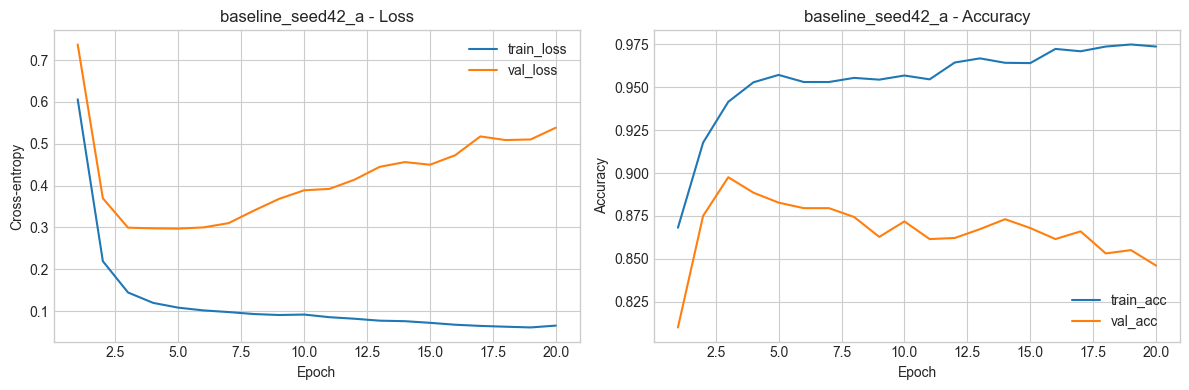

In [8]:
plot_history(baseline_a)


In [9]:
# Numerical reproducibility check for same-seed repeated run
ha = baseline_a['history']
hb = baseline_b['history']
max_abs_diff_best = abs(baseline_a['summary']['best_val_acc'] - baseline_b['summary']['best_val_acc'])
print('Same-seed best_val_acc difference:', max_abs_diff_best)
if len(ha['val_acc']) == len(hb['val_acc']):
    max_curve_diff = max(abs(a - b) for a, b in zip(ha['val_acc'], hb['val_acc']))
    print('Same-seed max epoch-wise val_acc difference:', max_curve_diff)


Same-seed best_val_acc difference: 0.0
Same-seed max epoch-wise val_acc difference: 0.0


## Overfitting Control
- weight decay
- early stopping


In [10]:
overfit_bad = add_run(RunConfig(
    name='overfit_bad',
    note='Intentional overfitting oversized MLP + long training + reduced fit subset',
    seed=123,
    split_seed=42,
    hidden_dims=(1024, 512, 256),
    dropout=0.0,
    weight_decay=0.0,
    epochs=120,
    lr=1e-3,
    fit_fraction=0.10,
    restore_best_weights=False,
))

overfit_fixed = add_run(RunConfig(
    name='overfit_fixed',
    note='Overfitting fix weight decay + early stopping only',
    seed=123,
    split_seed=42,
    hidden_dims=(1024, 512, 256),
    dropout=0.0,
    weight_decay=1e-4, # weight decay
    epochs=120,
    lr=1e-3,
    fit_fraction=0.10,
    early_stopping_patience=12, # early stopping
))

compare_runs([overfit_bad, overfit_fixed], title='Overfitting control: before vs after')
print('Before/after best validation accuracy delta:', round(overfit_fixed['summary']['best_val_acc'] - overfit_bad['summary']['best_val_acc'], 4))
print('Before/after final validation accuracy delta:', round(overfit_fixed['summary']['final_val_acc'] - overfit_bad['summary']['final_val_acc'], 4))
print('Bad run final train-val gap:', round(overfit_bad['summary']['generalization_gap_acc'], 4), '| Fixed run final train-val gap:', round(overfit_fixed['summary']['generalization_gap_acc'], 4))


[overfit_bad] best_val_acc=0.8247 @ epoch 17 | final_val_acc=0.7371 | final_train_acc=1.0000
[overfit_fixed] best_val_acc=0.8312 @ epoch 17 | final_val_acc=0.8312 | final_train_acc=0.9621
Overfitting control: before vs after


,run_name,seed,epochs_ran,best_epoch,best_val_acc,final_val_acc,final_train_acc,gap(train-val),failure_reason,note
0,overfit_bad,123,120,17,0.8247,0.7371,1.0000,0.2629,None,Intentional overfitting oversized MLP + long t...
1,overfit_fixed,123,29,17,0.8312,0.8312,0.9621,0.1309,None,Overfitting fix weight decay + early stopping ...


Before/after best validation accuracy delta: 0.0064
Before/after final validation accuracy delta: 0.0941
Bad run final train-val gap: 0.2629 | Fixed run final train-val gap: 0.1309


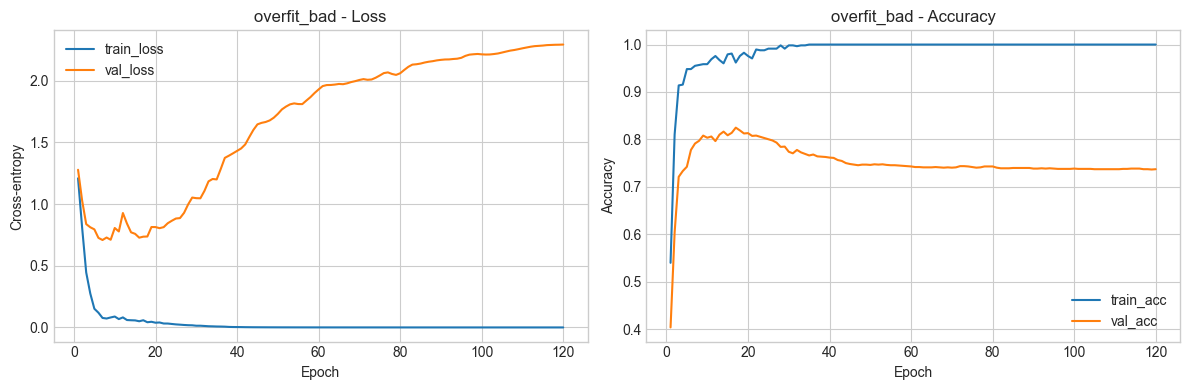

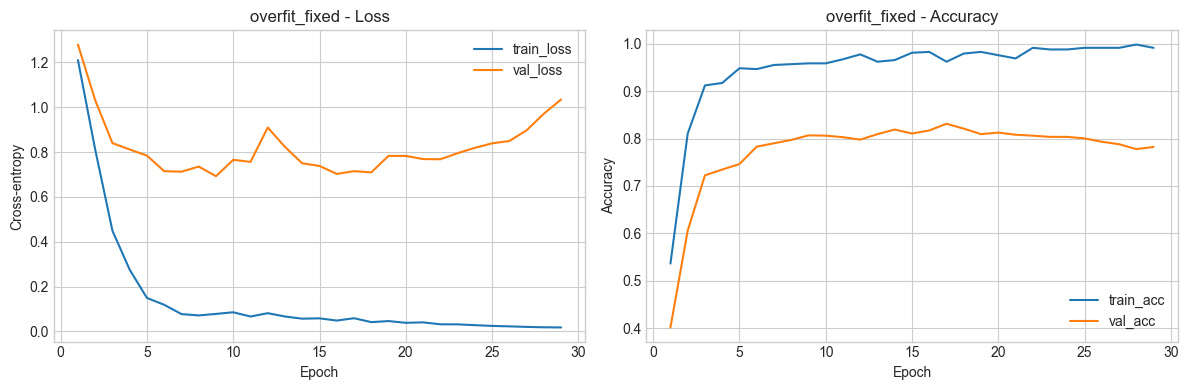

In [11]:
plot_history(overfit_bad)
plot_history(overfit_fixed)


## Severe Underfitting
- larger model capacity
- higher learning rate


In [12]:
underfit_bad = add_run(RunConfig(
    name='underfit_bad',
    note='Intentional severe underfitting tiny model + 3 epochs + very low LR',
    seed=314,
    split_seed=42,
    hidden_dims=(16,),
    dropout=0.0,
    epochs=3,
    lr=1e-5,
    weight_decay=1e-2,
))

underfit_fixed = add_run(RunConfig(
    name='underfit_fixed',
    note='Underfitting fix larger MLP + higher LR only',
    seed=314,
    split_seed=42,
    hidden_dims=(256, 128), # larger model capacity !
    dropout=0.0,
    epochs=3,
    lr=1e-3, # higher learning rate !
    weight_decay=1e-2,
))

compare_runs([underfit_bad, underfit_fixed], title='Failure-mode debug (severe underfitting): before vs after')
print('Before/after best validation accuracy delta:', round(underfit_fixed['summary']['best_val_acc'] - underfit_bad['summary']['best_val_acc'], 4))


[underfit_bad] best_val_acc=0.3686 @ epoch 3 | final_val_acc=0.3686 | final_train_acc=0.3767
[underfit_fixed] best_val_acc=0.8937 @ epoch 2 | final_val_acc=0.8937 | final_train_acc=0.9291
Failure-mode debug (severe underfitting): before vs after


,run_name,seed,epochs_ran,best_epoch,best_val_acc,final_val_acc,final_train_acc,gap(train-val),failure_reason,note
0,underfit_bad,314,3,3,0.3686,0.3686,0.3767,0.0082,None,Intentional severe underfitting tiny model + 3...
1,underfit_fixed,314,3,2,0.8937,0.8937,0.9291,0.0355,None,Underfitting fix larger MLP + higher LR only


Before/after best validation accuracy delta: 0.5251


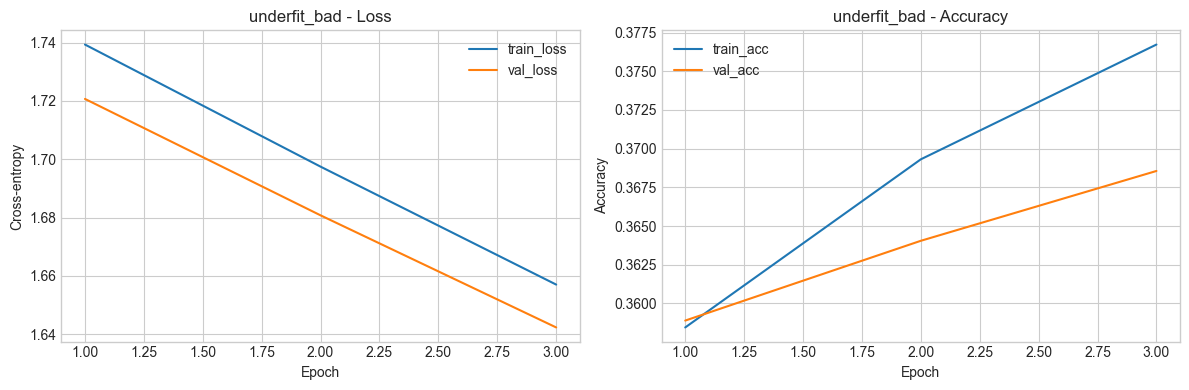

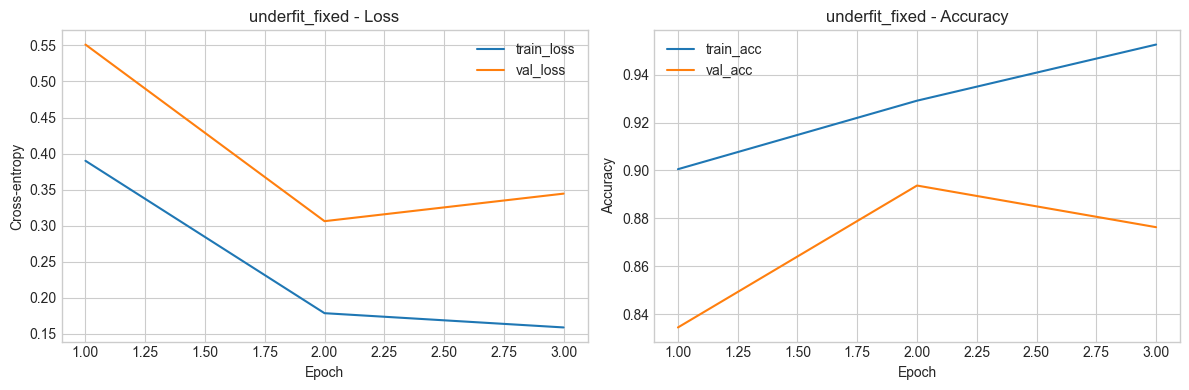

In [13]:
plot_history(underfit_bad)
plot_history(underfit_fixed)


## Log


In [14]:
log_rows = [r['summary'] for r in RUNS]
assert len(log_rows) >= 5, 'Need at least 5 runs logged.'

if pd is not None:
    log_df = pd.DataFrame(log_rows)
    display_cols = [
        'run_name', 'seed', 'split_seed', 'hidden_dims', 'epochs_requested', 'epochs_ran',
        'lr', 'weight_decay', 'dropout', 'scheduler', 'early_stopping_patience', 'noise_std',
        'fit_fraction', 'best_epoch', 'best_val_acc', 'final_val_acc', 'final_train_acc',
        'generalization_gap_acc', 'failure_reason', 'note'
    ]
    display(log_df[display_cols].sort_values('best_val_acc', ascending=False).reset_index(drop=True))
    log_df.to_csv('training_clinic_experiment_log.csv', index=False)
    print('Saved log to training_clinic_experiment_log.csv')
else:
    print(json.dumps(log_rows, indent=2))


,run_name,seed,split_seed,hidden_dims,epochs_requested,epochs_ran,lr,weight_decay,dropout,scheduler,early_stopping_patience,noise_std,fit_fraction,best_epoch,best_val_acc,final_val_acc,final_train_acc,generalization_gap_acc,failure_reason,note
0,baseline_seed42_a,42,42,"[128, 64]",20,20,0.00100,0.0000,0.0,none,NaN,0.0,1.0,3,0.897552,0.897552,0.941552,0.044000,None,Baseline MLP
1,baseline_seed42_b,42,42,"[128, 64]",20,20,0.00100,0.0000,0.0,none,NaN,0.0,1.0,3,0.897552,0.897552,0.941552,0.044000,None,Same config and same seed should closely match...
2,underfit_fixed,314,42,"[256, 128]",3,3,0.00100,0.0100,0.0,none,NaN,0.0,1.0,2,0.893686,0.893686,0.929138,0.035452,None,Underfitting fix larger MLP + higher LR only
3,baseline_seed7,7,42,"[128, 64]",20,20,0.00100,0.0000,0.0,none,NaN,0.0,1.0,4,0.893041,0.893041,0.947414,0.054373,None,Same config with different seed to show seed s...
4,overfit_fixed,123,42,"[1024, 512, 256]",120,29,0.00100,0.0001,0.0,none,12.0,0.0,0.1,17,0.831186,0.831186,0.962069,0.130883,None,Overfitting fix weight decay + early stopping ...
5,overfit_bad,123,42,"[1024, 512, 256]",120,120,0.00100,0.0000,0.0,none,NaN,0.0,0.1,17,0.824742,0.737113,1.000000,0.262887,None,Intentional overfitting oversized MLP + long t...
6,underfit_bad,314,42,[16],3,3,0.00001,0.0100,0.0,none,NaN,0.0,1.0,3,0.368557,0.368557,0.376724,0.008167,None,Intentional severe underfitting tiny model + 3...


Saved log to training_clinic_experiment_log.csv
